# 07 — Inference: from bundle on disk to deployment-ready predictions

The end of the tutorial chain. Earlier notebooks built the training
dataset, trained models, packaged them into bundles, and evaluated
them. This notebook shows the **deployment-facing API**:

```python
predictor = Predictor.from_bundle_dir(bundle_dir)
df = predictor.predict(
    coords=[(0.333542, 32.56863), (3.04679, 30.91350), ...],
    start_date=date(2024, 1, 1),
    end_date=date(2024, 12, 31),
)
# → long DataFrame: lat, lon, geohash5, date, ..., y_pred_kwh_m2_day
```

This is the call site the companion `Irradiation_Portal` Flask app
mirrors. If you change the bundle, you don't need to update the
portal — re-running this notebook is the smoke test.

## What's new in this notebook

```text
Predictor                                     (susse.inference)
    bundle: TrainedBundle
    service: FeatureService
    on_cache_miss: "raise" | "fetch"
    predict(coords, start_date, end_date) → DataFrame

PredictionRequest                             (dataclass — validated input)
    coords, start_date, end_date
```

## Notebook structure

| Step | What you'll see |
|---|---|
| 0  | Setup + load the paper bundle from `data/bundles/mukiibi_mikelson_2026/` |
| 1  | Single-point prediction: Kampala over 2024, with NASA / CAMS overlaid |
| 2  | Grid prediction: the Uganda 2024 inference cache (~1961 cells × 365 days) |
| 3  | Annual aggregation per cell |
| 4  | Folium choropleth — what the portal renders |
| 5  | Cache-miss diagnostics + the Phase B (on-demand fetch) follow-up |

## Two design choices worth knowing

* **The bundle is the source of truth.** `Predictor` reads
  `bundle.source_manifest.feature_selection` to know which NASA / CAMS
  variable IDs to assemble. Training and inference can never drift
  out of sync.
* **Cache miss is loud by default.** If you ask for a `(geohash5,
  date)` pair that isn't in the warehouse, you get a
  `RuntimeError` naming the missing cells — not a NaN, not a silent
  empty row. Phase B will add the optional on-demand NASA POWER +
  CAMS fetch path; for now, queries must hit cached cells.

### Inputs, outputs, and prerequisites

| | |
|---|---|
| **Inputs**  | The paper bundle at `data/bundles/mukiibi_mikelson_2026/`. The Uganda 2024 inference grid in the warehouse (the green-rectangle layer in `notebooks/tutorial/01_data_overview.ipynb`). |
| **Outputs** | None on disk — a long DataFrame in memory and a folium map. |
| **Prereqs** | BigQuery read access (`gcloud auth application-default login` locally; the Colab bootstrap handles it). The bundle must exist; run `notebooks/papers/mukiibi_mikelson_2026/01_recomputation.ipynb` once if not. |
| **Wall time** | ~30 seconds for §1 (one cell × 365 days), ~1 minute for §2 (whole Uganda grid). |

In [1]:
import shutil
import shlex
import sys
import os

PROJECT_ID = "solar-irradiation-estimation"

if "google.colab" in sys.modules:
    # --- GOOGLE COLAB AUTOMATED SETUP ---
    REPO = "Marconi-Lab/Solar_irradiation"
    BRANCH = "jm/add_model"
    clone_url = f"https://github.com{REPO}.git"
    
    if not os.path.exists("/content/Solar_irradiation/.git"):
        get_ipython().system(f"git clone -q -b {BRANCH} {clone_url} /content/Solar_irradiation")

    get_ipython().run_line_magic('cd', '/content/Solar_irradiation')
    get_ipython().system('pip install -q -e . 2>&1 | tail -3')

    from google.colab import auth
    auth.authenticate_user()
    get_ipython().system(f'gcloud config set project {PROJECT_ID} 2>/dev/null')
    print("Colab setup complete.")

else:
    # --- LOCAL WSL / LINUX AUTOMATED SETUP ---
    print("Running in Local Linux/WSL Environment.")
    os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
    
    # 1. Look for gcloud
    gcloud_path = shutil.which("gcloud")
    
    # Fallback check
    if not gcloud_path:
        home_bin = os.path.expanduser("~/google-cloud-sdk/bin/gcloud")
        if os.path.exists(home_bin):
            gcloud_path = home_bin

    # 2. Prevent installing if already found
    if not gcloud_path:
        print("SDK not found anywhere on the system. Installing now...")
        get_ipython().system('curl -sSL https://sdk.cloud.google.com | bash -s -- --disable-prompts > /dev/null')
        gcloud_path = os.path.expanduser("~/google-cloud-sdk/bin/gcloud")
    else:
        print(f"gcloud detected successfully at: {gcloud_path}")

    # FIXED: Use shlex.quote to safely wrap the windows/WSL path strings for Bash
    safe_gcloud_path = shlex.quote(gcloud_path)

    # 3. Trigger authentication using the safe, quoted path
    print("\nOpening your system browser for Google Cloud verification...")
    get_ipython().system(f'{safe_gcloud_path} auth application-default login')
    
    # 4. Set the project configuration
    get_ipython().system(f'{safe_gcloud_path} config set project {PROJECT_ID} 2>/dev/null')
    print(f"\nLocal setup complete! Active project set to: {PROJECT_ID}")

Running in Local Linux/WSL Environment.
gcloud detected successfully at: /mnt/c/Program Files (x86)/Google/Cloud SDK/google-cloud-sdk/bin/gcloud

Opening your system browser for Google Cloud verification...
Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=OmvcNU5lt1nhTRmivu3urfATrpjPS6&access_type=offline&code_challenge=i4vJwuvwIXg52Ztu1lPFJWEWRnrYEUghuaUQ2E_pO8k&code_challenge_method=S256

gio: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.goo

## 0 — Setup

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd

_HERE = Path.cwd().resolve()
_PROJECT_ROOT = _HERE
while _PROJECT_ROOT != _PROJECT_ROOT.parent and not (_PROJECT_ROOT / "src" / "susse").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent
sys.path.insert(0, str(_PROJECT_ROOT / "src"))

# Load .env so CAMS_EMAIL (used by the fetch-mode demo in §5) is
# picked up automatically. One helper across all notebooks.
from susse.env import load_project_env
load_project_env()

print(f"project root: {_PROJECT_ROOT}")

project root: /home/mukiibi/Github/SolarIrradiation


### Load the bundle

`Predictor.from_bundle_dir` is the one-liner the portal uses too. It
loads the trained model, the feature spec, the source manifest, and
opens a BigQuery client against the project default warehouse.

The `providers` argument supplies an elevation provider for
`AltitudeFeature` — pvlib's `lookup_altitude()` queries Open-Elevation
on the fly, so no warehouse trip is needed for that derived
feature.

In [3]:
from susse.inference import Predictor
from susse.preprocessing import PvlibElevationProvider

BUNDLE_DIR = (_PROJECT_ROOT / "data" / "bundles" / "mukiibi_mikelson_2026").resolve()
assert BUNDLE_DIR.exists(), (
    f"Bundle missing at {BUNDLE_DIR}. Run "
    f"notebooks/papers/mukiibi_mikelson_2026/01_recomputation.ipynb "
    f"end-to-end first."
)

predictor = Predictor.from_bundle_dir(
    BUNDLE_DIR,
    providers={"altitude": PvlibElevationProvider()},
    on_cache_miss="raise",
)
print(f"Bundle:        {BUNDLE_DIR.name}")
print(f"Trained at:    {predictor.bundle.metadata.created_at_utc}")
print(f"Splitter:      {predictor.bundle.metadata.splitter_name}")
print(f"Val RMSE:      {predictor.bundle.metadata.val_metrics.rmse:.3f}  "
      f"(val MAE {predictor.bundle.metadata.val_metrics.mae:.3f})")
print(f"Features:      {len(predictor.bundle.feature_spec.feature_columns)} raw + "
      f"{len(predictor.bundle.feature_spec.derived_features)} derived")

Bundle:        mukiibi_mikelson_2026
Trained at:    2026-06-24T11:36:53.542568+00:00
Splitter:      spatial_block[val=wadelai,kampala]
Val RMSE:      0.455  (val MAE 0.351)
Features:      16 raw + 2 derived


## 1 — Single-point prediction: Kampala over 2024

Kampala is one of the 28 training stations, so its geohash5 is
warehouse-cached for the full 2024 calendar year. The Predictor:

1. Computes geohash5 from `(lat, lon)`
2. Issues one batched query per source (irradiance + NASA aux + CAMS aux)
3. Assembles the inference frame and applies the bundle's `FeatureSpec` (cleaners disabled, no NaN-drop)
4. Runs the regressor in a single batched call

Result: 365 daily bias-corrected GHI predictions plus the raw NASA /
CAMS satellite columns so you can overlay them in plots without
re-querying.

In [4]:
KAMPALA_LAT = 0.333542
KAMPALA_LON = 32.56863

kampala = predictor.predict(
    coords=[(KAMPALA_LAT, KAMPALA_LON)],
    start_date=date(2024, 1, 1),
    end_date=date(2024, 12, 31),
)
print(f"Predictions: {len(kampala):,} rows × {len(kampala.columns)} columns")
print(f"Columns of interest:")
for c in ("lat", "lon", "geohash5", "date", "y_pred_kwh_m2_day",
          "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"):
    if c in kampala.columns:
        print(f"  {c}")
kampala.head()

Predictions: 366 rows × 25 columns
Columns of interest:
  lat
  lon
  geohash5
  date
  y_pred_kwh_m2_day
  sat_ghi_nasa_kwh_m2_day
  sat_ghi_cams_kwh_m2_day


,lat,lon,geohash5,date,location,nasa_longwave_downward_irr,nasa_aod_550_adj,nasa_cloud_amount,nasa_precipitable_water,nasa_airmass,...,sat_ghi_nasa_kwh_m2_day,sat_ghi_cams_kwh_m2_day,sat_dhi_nasa_kwh_m2_day,sat_dhi_cams_kwh_m2_day,sat_dni_nasa_kwh_m2_day,sat_dni_cams_kwh_m2_day,doy_sin,doy_cos,altitude_m,y_pred_kwh_m2_day
0,0.333542,32.56863,s8p1v,2024-01-01,point_0000,8.93,0.38,95.45,4.11,2.74,...,4.00,3.871717,2.47,2.933073,1.12,1.259727,0.000000,1.000000,1202.0,3.768108
1,0.333542,32.56863,s8p1v,2024-01-02,point_0000,8.91,0.29,78.95,4.03,2.73,...,4.52,3.449886,2.35,2.301082,2.57,2.037656,0.017166,0.999853,1202.0,3.657136
2,0.333542,32.56863,s8p1v,2024-01-03,point_0000,8.77,0.36,90.10,3.57,2.72,...,4.09,3.252947,2.73,2.207374,0.72,1.560007,0.034328,0.999411,1202.0,3.320477
3,0.333542,32.56863,s8p1v,2024-01-04,point_0000,8.73,0.41,69.66,3.10,2.72,...,5.80,5.975397,2.61,2.722464,3.73,4.329692,0.051479,0.998674,1202.0,5.380314
4,0.333542,32.56863,s8p1v,2024-01-05,point_0000,8.77,0.39,95.38,3.08,2.71,...,3.68,3.108820,2.39,2.489215,0.71,0.790917,0.068615,0.997643,1202.0,3.173131


### Time-series visualisation

The same convention as NB 06: the model's prediction is rendered
prominently with markers; the raw NASA / CAMS satellite estimates are
faint background lines so the visual contrast surfaces which series
the model *produced* vs the satellite *inputs* it bias-corrected.

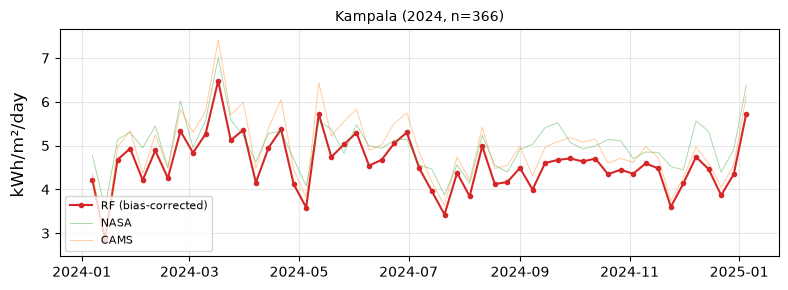

In [5]:
from susse.evaluation.plots import plot_training_fit_timeseries

# Single-station inference view — no observed series (we don't have
# ground GHI for arbitrary lat/lon at deploy time). The prediction is
# rendered prominently; NASA / CAMS sit faint in the background.
ts = kampala.copy()
ts["date"] = pd.to_datetime(ts["date"])
ts["location"] = "Kampala"

plot_training_fit_timeseries(
    ts,
    observed_column=None,
    prediction_series={"RF (bias-corrected)": "y_pred_kwh_m2_day"},
    reference_series={
        "NASA": "sat_ghi_nasa_kwh_m2_day",
        "CAMS": "sat_ghi_cams_kwh_m2_day",
    },
    location_column="location",
    n_stations=1,
)

## 2 — Grid prediction: the Uganda 2024 inference cache

The warehouse caches NASA + CAMS feature rows for every 0.05° geohash
cell in a Uganda bounding box across 2024. `01_data_overview.ipynb`
renders these as a green rectangle on its coverage map; here we
query the cell centres and predict for the whole grid.

The query below pulls the cell centroids straight from BigQuery so
we never duplicate the grid definition. ~2k cells × 365 days = ~700k
predictions; the bundle's RF is batched, so this takes about a
minute even on a workstation.

In [6]:
from susse.warehouse_ops.io import BigQueryClient, WarehouseConfig
from susse.warehouse_ops.io.config import TableRefs

bq = BigQueryClient(config=WarehouseConfig())
tables = TableRefs(config=bq.config)

# Cell centres of the Uganda 2024 grid (the 2024-only NASA cells the
# warehouse caches for portal inference, excluding ground stations).
grid_cells = bq.query(f"""
SELECT DISTINCT geohash5,
                ANY_VALUE(latitude)  AS lat,
                ANY_VALUE(longitude) AS lon
FROM `{tables.irradiance_daily}`
WHERE date BETWEEN DATE('2024-01-01') AND DATE('2024-12-31')
  AND source = 'NASA'
  AND geohash5 NOT IN (SELECT DISTINCT geohash5 FROM `{tables.ground_measurements}`)
GROUP BY geohash5
ORDER BY lat, lon
""")
print(f"Uganda 2024 grid: {len(grid_cells):,} cells")
grid_cells.head()

Uganda 2024 grid: 2,183 cells


,geohash5,lat,lon
0,kxszr,-1.5,29.50
1,kxtp2,-1.5,29.54
2,kxtp3,-1.5,29.58
3,kxtp6,-1.5,29.66
4,kxtp7,-1.5,29.70


In [7]:
uganda_2024 = predictor.predict(
    coords=list(zip(grid_cells["lat"], grid_cells["lon"])),
    start_date=date(2024, 1, 1),
    end_date=date(2024, 12, 31),
)
print(f"Daily predictions: {len(uganda_2024):,} rows  "
      f"({uganda_2024[['lat', 'lon']].drop_duplicates().shape[0]:,} unique cells × "
      f"{uganda_2024['date'].nunique()} days)")

Daily predictions: 798,978 rows  (2,183 unique cells × 366 days)


## 3 — Annual aggregation per cell

The portal renders an **annual-mean** GHI choropleth. Reduce the
daily long-format frame to one row per cell carrying its 2024 mean
predicted GHI plus the two satellite baselines for comparison.

In [8]:
annual = (
    uganda_2024
    .groupby(["lat", "lon", "geohash5"], as_index=False)
    .agg(
        rf_mean=("y_pred_kwh_m2_day", "mean"),
        nasa_mean=("sat_ghi_nasa_kwh_m2_day", "mean"),
        cams_mean=("sat_ghi_cams_kwh_m2_day", "mean"),
    )
)
print(f"Annual mean grid: {len(annual):,} cells")
print(f"  RF   range: {annual['rf_mean'].min():.2f} – {annual['rf_mean'].max():.2f} kWh/m²/day")
print(f"  NASA range: {annual['nasa_mean'].min():.2f} – {annual['nasa_mean'].max():.2f}")
print(f"  CAMS range: {annual['cams_mean'].min():.2f} – {annual['cams_mean'].max():.2f}")
annual.head()

Annual mean grid: 2,183 cells
  RF   range: 3.67 – 5.91 kWh/m²/day
  NASA range: 4.76 – 5.87
  CAMS range: 3.77 – 6.48


,lat,lon,geohash5,rf_mean,nasa_mean,cams_mean
0,-1.5,29.50,kxszr,4.148680,4.760119,4.44633
1,-1.5,29.54,kxtp2,4.148680,4.760119,4.44633
2,-1.5,29.58,kxtp3,4.148680,4.760119,4.44633
3,-1.5,29.66,kxtp6,4.145657,4.760119,4.44633
4,-1.5,29.70,kxtp7,4.203454,4.760119,4.44633


## 4 — Folium choropleth — what the portal renders

A small circle marker per cell, coloured by predicted annual GHI.
This is the static analogue of the portal's interactive heatmap; the
portal uses the same DataFrame with `folium.raster_layers.ImageOverlay`
for a rasterised version.

In [12]:
import folium
import branca.colormap as cm

cmap = cm.LinearColormap(
    colors=["#440154", "#3b528b", "#21918c", "#5ec962", "#fde725"],
    vmin=float(annual["rf_mean"].min()),
    vmax=float(annual["rf_mean"].max()),
    caption="RF-corrected annual mean GHI (kWh/m²/day)",
)

centre_lat = float(annual["lat"].mean())
centre_lon = float(annual["lon"].mean())
m = folium.Map(location=[centre_lat, centre_lon], zoom_start=7, control_scale=True)
for _, row in annual.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]], radius=4,
        color=None, fill=True,
        fillColor=cmap(row["rf_mean"]), fillOpacity=0.85,
        popup=folium.Popup(
            f"<b>geohash5</b>: {row['geohash5']}<br>"
            f"<b>RF</b>:   {row['rf_mean']:.2f} kWh/m²/day<br>"
            f"<b>NASA</b>: {row['nasa_mean']:.2f}<br>"
            f"<b>CAMS</b>: {row['cams_mean']:.2f}",
            max_width=240,
        ),
    ).add_to(m)
cmap.add_to(m)
m

## 5 — Cache misses + on-demand fetch (Phase B)

The Predictor's default behaviour is loud-by-default: any requested
`(geohash5, date)` pair that isn't in the warehouse raises a
`RuntimeError` naming the missing cells. That's what the
`on_cache_miss="raise"` constructor mode you've been using does.

In [10]:
# A point in the Indian Ocean — definitely not in any cache.
try:
    predictor.predict(
        coords=[(-5.0, 70.0)],
        start_date=date(2024, 1, 1), end_date=date(2024, 1, 7),
    )
except RuntimeError as e:
    print("Cache miss surfaced as expected:")
    print(str(e)[:400], "...")

Cache miss surfaced as expected:
Predictor: 7 warehouse cell-day pairs are missing. Apply the corresponding warehouse-ingest migration before calling predict, or construct the Predictor with on_cache_miss='fetch' to fetch on demand (requires CAMS_EMAIL + BQ write perms). First few missing (geohash5, date): [('mx1g8', datetime.date(2024, 1, 1)), ('mx1g8', datetime.date(2024, 1, 2)), ('mx1g8', datetime.date(2024, 1, 3)), ('mx1g8',  ...


### Switching to `on_cache_miss="fetch"`

With `on_cache_miss="fetch"`, the predictor instead invokes the
existing `NasaPowerSatelliteJob` and `CamsSatelliteJob` to fetch +
persist the missing cells before re-querying and predicting. The
same code path the batch-ingest migrations use — same schema, same
idempotency, same hardening — wrapped one layer up.

**Prerequisites for fetch mode:**

* `CAMS_EMAIL` env var set to a registered [SoDa-Pro](https://www.soda-pro.com/web-services/radiation/cams-radiation-service)
  account. The constructor raises `ValueError` upfront if missing.
* BigQuery write access on the warehouse dataset. Failure surfaces at
  the first write.
* Implicit cap of **30 cells per `predict()`** to respect CAMS's free-tier
  daily quota — exceeding it raises rather than silently throttling.

A typical interactive single-coord query for an uncached cell takes
~25-40 seconds: NASA POWER fetch (~5s) + CAMS fetch (~10s) + warehouse
write (~5-10s) + warehouse re-query (~3s) + predict (~1s). Subsequent
queries for the same cell hit the warehouse and run in ~3 seconds.

In [11]:
import os

# `load_dotenv()` was already called in §0, so a CAMS_EMAIL set in
# `.env` is already in os.environ here. Either path (shell export or
# .env entry) makes this cell light up.
if not os.environ.get("CAMS_EMAIL"):
    print("CAMS_EMAIL is not set; skipping the fetch-mode demo.\n"
          "Either `export CAMS_EMAIL=you@example.com` in the shell, or\n"
          "add `CAMS_EMAIL=you@example.com` to a `.env` at the project\n"
          "root, then restart the kernel.")
else:
    fetch_predictor = Predictor.from_bundle_dir(
        BUNDLE_DIR,
        providers={"altitude": PvlibElevationProvider()},
        on_cache_miss="fetch",
    )
    # A single uncached coord — Lake Albert, on the Uganda/DRC border.
    # If the Uganda 2024 grid covered it already, this hits the cache;
    # otherwise the fetch path fires.
    lake_albert = fetch_predictor.predict(
        coords=[(1.6, 30.85)],
        start_date=date(2024, 6, 1),
        end_date=date(2024, 6, 7),
    )
    print(f"Predictions: {len(lake_albert)} rows")
    print(lake_albert[["lat", "lon", "date", "y_pred_kwh_m2_day"]].to_string(index=False))

Predictions: 7 rows
 lat   lon       date  y_pred_kwh_m2_day
 1.6 30.85 2024-06-01           5.114731
 1.6 30.85 2024-06-02           5.555609
 1.6 30.85 2024-06-03           3.907290
 1.6 30.85 2024-06-04           3.773521
 1.6 30.85 2024-06-05           5.444831
 1.6 30.85 2024-06-06           5.402184
 1.6 30.85 2024-06-07           5.823378


## What's next

* **`Irradiation_Portal`** — the Flask portal already loads a bundle
  via `load_bundle(...)`. The next portal release should switch to
  `Predictor.from_bundle_dir(...)` so the portal and the tutorial
  evolve together. The portal also gets free warehouse caching: any
  user query for an uncached cell, while `on_cache_miss="fetch"`,
  populates the warehouse for the next user.
* **Inspection notebooks** — `notebooks/inspection/` is the right
  place for ad-hoc deployment-readiness checks (per-region bias,
  out-of-distribution probe coordinates, model-vs-model overlays).

The discipline going forward:

| Change | What ripples |
|---|---|
| New model kind | New `BaseRegressor` subclass + params. Predictor signature unchanged. |
| New satellite source | New `Source` enum value + ingest job + entry in `_LONG_AUX_TABLES`. Predictor signature unchanged. |
| New derived feature | New `DerivedFeature` subclass; FeatureSpec gains a tuple entry. Predictor signature unchanged. |
| Cache-miss policy change | `Predictor.on_cache_miss` is a knob; portal flips it. |

The `Predictor` is the unit of deployment. The portal owns a single
instance and reuses it across requests. If something here feels
missing — a request-level metric you want logged, an artifact
provenance field that should travel into every response — extend the
`Predictor` (not the call site).